In [1]:
import pandas as pd 
import numpy as np 
from alphagenome import colab_utils
from alphagenome.data import genome
from alphagenome.models import dna_client
from alphagenome.models import variant_scorers

/opt/anaconda3/envs/opensplicerna/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [13]:
from dotenv import load_dotenv
import os

load_dotenv("../.env")
api_key = os.environ["ALPHA_GENOME_API_KEY"] #api key I generated from google deepmind

In [14]:
from alphagenome.models import dna_client

dna_model = dna_client.create(api_key)

In [15]:
splicing_scorers = [
    variant_scorers.RECOMMENDED_VARIANT_SCORERS['SPLICE_SITES'],
    variant_scorers.RECOMMENDED_VARIANT_SCORERS['SPLICE_SITE_USAGE'],
    variant_scorers.RECOMMENDED_VARIANT_SCORERS['SPLICE_JUNCTIONS'],
]

for scorer in splicing_scorers:
  print(f'{scorer.name} (signed={scorer.is_signed})')

GeneMaskSplicingScorer(requested_output=SPLICE_SITES, width=None) (signed=False)
GeneMaskSplicingScorer(requested_output=SPLICE_SITE_USAGE, width=None) (signed=False)
SpliceJunctionScorer() (signed=False)


In [16]:
# Define a variant near a splice site in the BRCA2 gene.
variant = genome.Variant(
    chromosome='chr13',
    position=32316462,
    reference_bases='T',
    alternate_bases='G',
)

# Create a 1MB interval centered on the variant.
interval = variant.reference_interval.resize(dna_client.SEQUENCE_LENGTH_1MB)

# Score the variant using the splicing scorers.
scores = dna_model.score_variant(
    interval=interval,
    variant=variant,
    variant_scorers=splicing_scorers,
    organism=dna_client.Organism.HOMO_SAPIENS,
)

# View the tidy scores.
df_scores = variant_scorers.tidy_scores([scores])
df_scores

,variant_id,scored_interval,gene_id,gene_name,gene_type,gene_strand,junction_Start,junction_End,output_type,variant_scorer,...,track_strand,Assay title,ontology_curie,biosample_name,biosample_type,biosample_life_stage,gtex_tissue,data_source,raw_score,quantile_score
0,chr13:32316462:T>G,chr13:31792174-32840750:.,ENSG00000139618,BRCA2,protein_coding,+,None,None,SPLICE_SITES,GeneMaskSplicingScorer(requested_output=SPLICE...,...,.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.011108,0.765994
1,chr13:32316462:T>G,chr13:31792174-32840750:.,ENSG00000139618,BRCA2,protein_coding,+,None,None,SPLICE_SITES,GeneMaskSplicingScorer(requested_output=SPLICE...,...,.,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.003906,0.045249
2,chr13:32316462:T>G,chr13:31792174-32840750:.,ENSG00000139618,BRCA2,protein_coding,+,None,None,SPLICE_SITE_USAGE,GeneMaskSplicingScorer(requested_output=SPLICE...,...,.,polyA plus RNA-seq,CL:0000047,neuronal stem cell,in_vitro_differentiated_cells,embryonic,,encode,0.007812,0.525389
3,chr13:32316462:T>G,chr13:31792174-32840750:.,ENSG00000139618,BRCA2,protein_coding,+,None,None,SPLICE_SITE_USAGE,GeneMaskSplicingScorer(requested_output=SPLICE...,...,.,total RNA-seq,CL:0000062,osteoblast,primary_cell,adult,,encode,0.011719,0.946842
4,chr13:32316462:T>G,chr13:31792174-32840750:.,ENSG00000139618,BRCA2,protein_coding,+,None,None,SPLICE_SITE_USAGE,GeneMaskSplicingScorer(requested_output=SPLICE...,...,.,polyA plus RNA-seq,CL:0000084,T-cell,primary_cell,adult,,encode,0.011719,0.958945
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2199,chr13:32316462:T>G,chr13:31792174-32840750:.,ENSG00000139618,BRCA2,protein_coding,+,32315667,32319076,SPLICE_JUNCTIONS,SpliceJunctionScorer(),...,.,total RNA-seq,UBERON:0036149,suprapubic skin,tissue,adult,,encode,0.052551,0.985728
2200,chr13:32316462:T>G,chr13:31792174-32840750:.,ENSG00000139618,BRCA2,protein_coding,+,32316527,32325075,SPLICE_JUNCTIONS,SpliceJunctionScorer(),...,.,total RNA-seq,UBERON:0036149,suprapubic skin,tissue,adult,,encode,0.050415,0.984743
2201,chr13:32316462:T>G,chr13:31792174-32840750:.,ENSG00000139618,BRCA2,protein_coding,+,32316391,32319076,SPLICE_JUNCTIONS,SpliceJunctionScorer(),...,.,total RNA-seq,UBERON:0036149,suprapubic skin,tissue,adult,,encode,0.045563,0.982567
2202,chr13:32316462:T>G,chr13:31792174-32840750:.,ENSG00000139618,BRCA2,protein_coding,+,32316391,32316421,SPLICE_JUNCTIONS,SpliceJunctionScorer(),...,.,total RNA-seq,UBERON:0036149,suprapubic skin,tissue,adult,,encode,0.014336,0.753630


In [17]:
# Define a variant near a splice site in the BRCA2 gene.
variant = genome.Variant(
    chromosome='chr22',
    position=36201698,
    reference_bases='A',
    alternate_bases='C',
)

# Create a 1MB interval centered on the variant.
interval = variant.reference_interval.resize(dna_client.SEQUENCE_LENGTH_1MB)

# Predict junction counts for both REF and ALT alleles
output = dna_model.predict_variant(
    interval=interval,
    variant=variant,
    requested_outputs=[dna_client.OutputType.SPLICE_JUNCTIONS],
    ontology_terms=['CL:0000084'],
)

In [18]:
print(f"Junctions shape: {output.reference.splice_junctions.junctions.shape}")
print(f"Value shape: {output.reference.splice_junctions.values.shape}")


Junctions shape: (107,)
Value shape: (107, 2)


In [19]:
output.reference.splice_junctions.metadata

,name,ontology_curie,biosample_name,biosample_type,biosample_life_stage,gtex_tissue,data_source,Assay title
0,junction_CL:0000084 polyA plus RNA-seq,CL:0000084,T-cell,primary_cell,adult,,encode,polyA plus RNA-seq
1,junction_CL:0000084 total RNA-seq,CL:0000084,T-cell,primary_cell,adult,,encode,total RNA-seq


In [20]:
def compute_psi_from_raw(junction_data, track_idx):
  # Create the dataframe from known attributes
  data = []
  for i, j in enumerate(junction_data.junctions):
    # Determine Donor and Acceptor based on strand
    if j.strand == '+':
      donor, acceptor = j.start, j.end
    else:
      donor, acceptor = j.end, j.start

    data.append({
        'donor': donor,
        'acceptor': acceptor,
        'count': junction_data.values[i, track_idx],
    })

  df = pd.DataFrame(data)

  # Pivot into the matrix: Rows = Donors, Cols = Acceptors
  matrix = df.pivot_table(
      index='donor', columns='acceptor', values='count', fill_value=0
  )

  # PSI5: Normalize row-wise (Percent of donor usage for each acceptor)
  # PSI5 = Count / (Total counts for that Donor)
  psi5 = matrix.div(matrix.sum(axis=1), axis=0).fillna(0)

  # PSI3: Normalize column-wise (Percent of acceptor usage for each donor)
  # PSI3 = Count / (Total counts for that Acceptor)
  psi3 = matrix.div(matrix.sum(axis=0), axis=1).fillna(0)

  return psi5, psi3

In [21]:
# We can use either RNA track for PSI values
titles = (
    output.reference.splice_junctions.metadata['Assay title']
    .astype(str)
    .tolist()
)
polya_idx = next(
    (i for i, t in enumerate(titles) if 'polya' in t.lower()), None
)
total_idx = next(
    (i for i, t in enumerate(titles) if 'total' in t.lower()), None
)

# Indecies
print(f'Indices found -> PolyA: {polya_idx}, Total: {total_idx}')

# Calululate PSI
psi5_total, psi3_total = compute_psi_from_raw(
    output.reference.splice_junctions, polya_idx
)

Indices found -> PolyA: 0, Total: 1


In [22]:
print(
    'The proportion of total splicing activity at a specific acceptor site that'
    ' is contributed by a given donor'
)
display(psi3_total.head())

print(
    'The proportion of total splicing activity at a specific donor site that is'
    ' directed to a given acceptor'
)
display(psi5_total.head())

The proportion of total splicing activity at a specific acceptor site that is contributed by a given donor


acceptor,36191912,36195432,36195437,36197831,36198896,36199369,36199376,36199608,36200291,36201796,36201851,36201888,36202055,36202094,36202933
donor,,,,,,,,,,,,,,,
36192925,0.018932,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
36195094,0.017024,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
36195310,0.908375,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
36195912,0.004841,0.093757,0.016779,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
36197944,0.005110,0.087324,0.017659,0.100873,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


The proportion of total splicing activity at a specific donor site that is directed to a given acceptor


acceptor,36191912,36195432,36195437,36197831,36198896,36199369,36199376,36199608,36200291,36201796,36201851,36201888,36202055,36202094,36202933
donor,,,,,,,,,,,,,,,
36192925,1.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
36195094,1.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
36195310,1.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
36195912,0.153898,0.215750,0.630352,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
36197944,0.130025,0.160849,0.531023,0.178103,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [24]:
from alphagenome import colab_utils
from alphagenome.data import gene_annotation
from alphagenome.data import genome
from alphagenome.data import transcript as transcript_utils
from alphagenome.models import dna_client
from alphagenome.models import variant_scorers
from alphagenome.visualization import plot_components
import matplotlib.pyplot as plt
import pandas as pd

# The GTF file contains information on the location of all transcripts.
# Note that we use genome assembly hg38 for human.
gtf = pd.read_feather(
    'https://storage.googleapis.com/alphagenome/reference/gencode/'
    'hg38/gencode.v46.annotation.gtf.gz.feather'
)

# All transcripts
transcript_extractor_all = transcript_utils.TranscriptExtractor(gtf)

# All protein-coding transcripts
gtf_protein = gene_annotation.filter_protein_coding(gtf)
transcript_extractor_protein = transcript_utils.TranscriptExtractor(gtf_protein)

# All MANE transcripts
gtf_mane = gene_annotation.filter_to_mane_select_transcript(gtf)
transcript_extractor_mane = transcript_utils.TranscriptExtractor(gtf_mane)

# All MANE protein-coding transcripts
gtf_mane_protein = gene_annotation.filter_protein_coding(gtf)
gtf_mane_protein = gene_annotation.filter_to_mane_select_transcript(
    gtf_mane_protein
)
transcript_extractor_mane_protein = transcript_utils.TranscriptExtractor(
    gtf_mane_protein
)


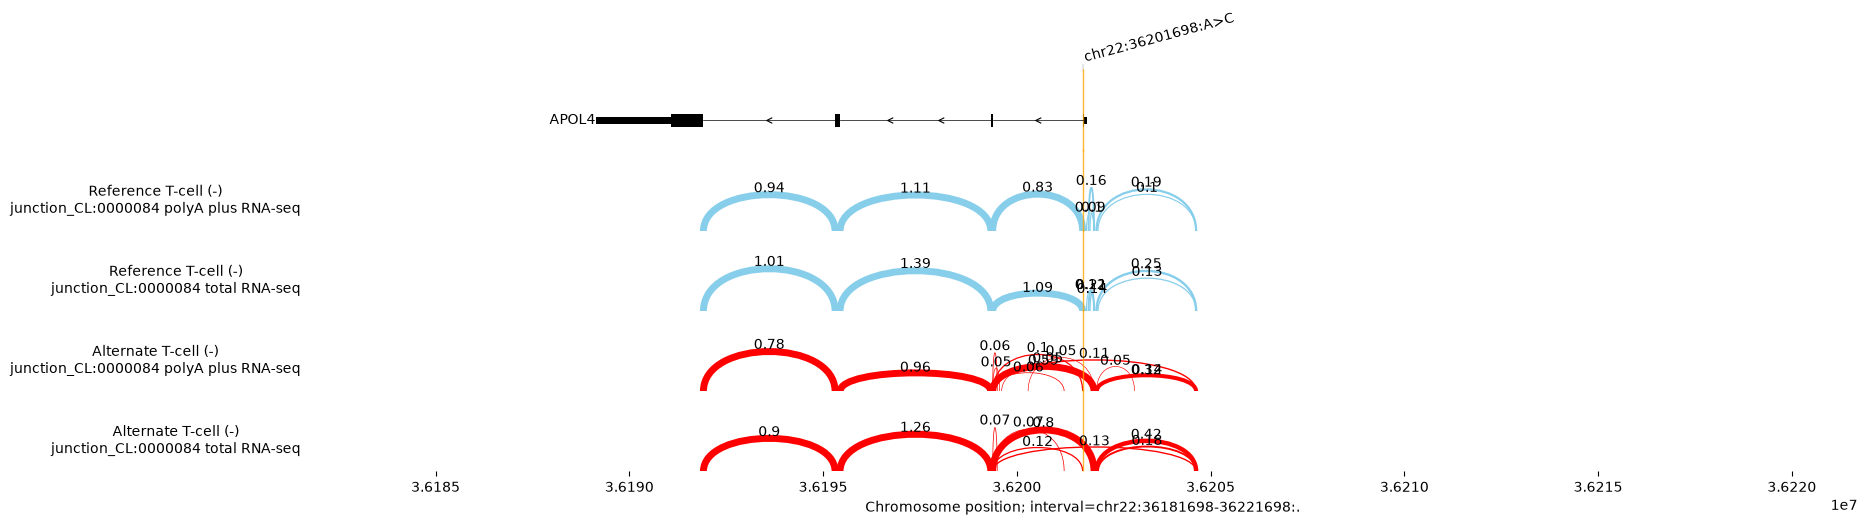

In [25]:
# We will plot for both polyA and total RNA-seq
ref_output = output.reference
alt_output = output.alternate

# Plot
_ = plot_components.plot(
    [
        # Transcript annotations
        plot_components.TranscriptAnnotation(
            transcript_extractor_mane.extract(interval)
        ),
        # Sashimi ref and alt plots
        plot_components.Sashimi(
            ref_output.splice_junctions,
            ylabel_template='Reference {biosample_name} ({strand})\n{name}',
            color='skyblue',
        ),
        plot_components.Sashimi(
            alt_output.splice_junctions,
            ylabel_template='Alternate {biosample_name} ({strand})\n{name}',
            color='red',
        ),
    ],
    # Annotate the variant position as a vertical line across all panels
    annotations=[plot_components.VariantAnnotation([variant])],
    interval=interval.resize(40000),
)

plt.show()

In [26]:
# replicating the opensplice data first for an exon

df = pd.read_csv('../open_splice_experimental_master_unique_sequence_all_predictor_cols.tsv', sep='\t')
print(df.iloc[0])

CHROM                                                           chr13
POS                                                          32326036
REF                                                                 T
ALT                                                                 A
gene                                                            BRCA2
                                                               ...   
alphagenome_minigene__alphagenome_minigene_acceptor_mut      0.057129
alphagenome_minigene__alphagenome_minigene_donor_mut         0.043701
alphagenome_minigene__alphagenome_minigene_delta_acceptor   -0.023926
alphagenome_minigene__alphagenome_minigene_delta_donor      -0.015381
alphagenome_minigene__alphagenome_minigene_delta_mean       -0.019653
Name: 0, Length: 169, dtype: object


In [28]:
for col, val in df.iloc[0, (list(range(0,52)) + list(range(161,169)))].items():
    print(f'{col}: {val}\n')

CHROM: chr13

POS: 32326036

REF: T

ALT: A

gene: BRCA2

exon_id: BRCA2_e5

ensembl_exon_id: ENSE00003739878

variant_id: BRCA2_e5_T6A

nt_seq: AAAAAAAAGATAAACTAGTTTTTGCCAGTTTTTTAAAATAACCTAAGGGATTTGCTTTGTTTTATTTTAGTCCTGTTGTTCTACAATGTACACATGTAACACCACAAAGAGATAAGTCAGGTATGATTAAAAACAATGCTTTTTA

lib_id: MUT1

exp: MUT1

start: 6

end: 6

start_corr: -65.0

end_corr: -65.0

length: 1

wt: U

mut: A

mut_type: sub

region: Intron up

region_start: Intron up

region_end: Intron up

exon_length: 50.0

psi_r1: 71.1111111111111

psi_r2: 45.7142857142857

psi_r3: 37.1428571428572

wt_psi: 59.5933199444304

se_wt_psi: 0.434443523512136

psi: 59.8363706711098

delta_psi: 0.243050726679395

se_psi: 3.65350702174463

logit_psi_wt: 0.388548367111636

logit_psi: 0.398651838241759

delta_logit: 0.010103471130123

se: 0.152023858877463

se_wt: 0.0180419127323624

se_d: 0.153090706063552

z: 0.0659966329107448

p: 0.947380506160048

padj: 0.955082786697935

significant: no

measured: True

delta_bin: mid



In [29]:
row = df.iloc[0]

mut_seq = row["nt_seq"]

mutation_pos = int(row["start"]) - 1  # convert 1-based to 0-based

print("mutant base:", mut_seq[mutation_pos])
print("ALT:", row["ALT"])

wt_seq = list(mut_seq)
wt_seq[mutation_pos] = row["REF"]
wt_seq = "".join(wt_seq)

print("WT base:", wt_seq[mutation_pos])
print("MUT base:", mut_seq[mutation_pos])

mutant base: A
ALT: A
WT base: T
MUT base: A


In [30]:
upstream = mut_seq[:70]
exon = mut_seq[70:120]
downstream = mut_seq[120:]

print(len(upstream), len(exon), len(downstream))

70 50 25


In [31]:
row = df.iloc[0]

seq = row["nt_seq"]

print("nt_seq length:", len(seq))
print("exon_length:", row["exon_length"])

print("upstream:", seq[:70], len(seq[:70]))
print("exon:", seq[70:70 + int(row["exon_length"])],
      len(seq[70:70 + int(row["exon_length"])]))
print("downstream:", seq[70 + int(row["exon_length"]):],
      len(seq[70 + int(row["exon_length"]):]))


nt_seq length: 145
exon_length: 50.0
upstream: AAAAAAAAGATAAACTAGTTTTTGCCAGTTTTTTAAAATAACCTAAGGGATTTGCTTTGTTTTATTTTAG 70
exon: TCCTGTTGTTCTACAATGTACACATGTAACACCACAAAGAGATAAGTCAG 50
downstream: GTATGATTAAAAACAATGCTTTTTA 25


In [33]:
from alphagenome.models import dna_client
from alphagenome.models.dna_output import OutputType

In [34]:
#from opensplice github

fas_e5 = (
    "ATGTGAACATGGAATCATCAAGGAATGCACACTCACCAGCAACACCAAGTGCAAAGAGGAAG"
)

fas_i5 = (
    "GTAATTATTTTTTTACGGTTATATTCTCCTTTCCCCCAACCCCATGGAAAGATGTGAAG"
    "AAAAACCAATCACTCTTGATTACTA"
)

fas_i6 = (
    "CAGATTGAAATAACTTGGGAAGTAGTTTCTCTTAGTGTGAAAGTATGTTCTCACATGCATT"
    "CTACAAGGCTGAGACCTGAGTTGATAAAATTTCTTTGTTCTTTCAG"
)

fas_e7 = (
    "TGAAGAGAAAGGAAGTACAGAAAACATGCAGAAAGCACAGAAAGGAA"
)

pre_manual = fas_e5 + fas_i5
post_manual = fas_i6 + fas_e7

print(len(pre_manual))   # 146
print(len(post_manual))  # 154

146
154


In [35]:
row = df.iloc[0]

mut_seq = row["nt_seq"]

print(len(mut_seq))                 # 145
print(int(row["exon_length"]))      # 50

145
50


In [36]:
mut_pos0 = int(row["start"]) - 1

wt_seq = list(mut_seq)
wt_seq[mut_pos0] = row["REF"]
wt_seq = "".join(wt_seq)

print(mut_seq[mut_pos0], row["ALT"])
print(wt_seq[mut_pos0], row["REF"])

A A
T T


In [37]:
wt_core = pre_manual + wt_seq + post_manual
mut_core = pre_manual + mut_seq + post_manual

In [38]:
UPSTREAM_LEN = 70

acceptor_construct_pos0 = len(pre_manual) + UPSTREAM_LEN

donor_construct_pos0 = (
    acceptor_construct_pos0
    + int(row["exon_length"])
    - 1
)

print("pre_manual:", len(pre_manual))
print("acceptor:", acceptor_construct_pos0)
print("donor:", donor_construct_pos0)

pre_manual: 146
acceptor: 216
donor: 265


In [39]:
import numpy as np

from alphagenome.models import dna_client
from alphagenome.models.dna_output import OutputType


TARGET_LEN = 2**14   # 16384


def clean_seq(seq):
    seq = str(seq).upper()
    return "".join(
        b if b in {"A", "C", "G", "T", "N"} else "N"
        for b in seq
    )


def pad_construct(core_seq, target_len=TARGET_LEN):
    core_seq = clean_seq(core_seq)

    left_pad = (target_len - len(core_seq)) // 2
    right_pad = target_len - len(core_seq) - left_pad

    padded = (
        "N" * left_pad
        + core_seq
        + "N" * right_pad
    )

    return padded, left_pad, right_pad


def get_positive_strand_tracks(pred_out):
    ss = pred_out.splice_sites.filter_to_positive_strand()

    arr = np.asarray(ss.values)
    names = [str(n).lower() for n in ss.names]

    donor_idx = names.index("donor")
    acceptor_idx = names.index("acceptor")

    donor = arr[:, donor_idx]
    acceptor = arr[:, acceptor_idx]

    return donor, acceptor

In [40]:
row = df.iloc[0]

mut_seq = clean_seq(row["nt_seq"])

# reconstruct WT from mutant row
mut_pos0 = int(row["start"]) - 1

wt_seq = list(mut_seq)
wt_seq[mut_pos0] = row["REF"]
wt_seq = "".join(wt_seq)

print("variant:", row["variant_id"])
print("mut pos:", mut_pos0)
print("WT base:", wt_seq[mut_pos0])
print("MUT base:", mut_seq[mut_pos0])

variant: BRCA2_e5_T6A
mut pos: 5
WT base: T
MUT base: A


In [41]:
wt_core = clean_seq(
    pre_manual
    + wt_seq
    + post_manual
)

mut_core = clean_seq(
    pre_manual
    + mut_seq
    + post_manual
)

print("WT core length:", len(wt_core))
print("MUT core length:", len(mut_core))

WT core length: 445
MUT core length: 445


In [42]:
exon_len = int(row["exon_length"])

acceptor_construct_pos0 = 216
donor_construct_pos0 = 216 + exon_len - 1

print("acceptor construct pos:", acceptor_construct_pos0)
print("donor construct pos:", donor_construct_pos0)

acceptor construct pos: 216
donor construct pos: 265


In [43]:
wt_padded, wt_left_pad, wt_right_pad = pad_construct(wt_core)
mut_padded, mut_left_pad, mut_right_pad = pad_construct(mut_core)

print(len(wt_padded), len(mut_padded))
print("WT left pad:", wt_left_pad)
print("MUT left pad:", mut_left_pad)

16384 16384
WT left pad: 7969
MUT left pad: 7969


In [44]:
wt_acceptor_pos = wt_left_pad + acceptor_construct_pos0
wt_donor_pos = wt_left_pad + donor_construct_pos0

mut_acceptor_pos = mut_left_pad + acceptor_construct_pos0
mut_donor_pos = mut_left_pad + donor_construct_pos0

print("WT acceptor padded:", wt_acceptor_pos)
print("WT donor padded:", wt_donor_pos)

WT acceptor padded: 8185
WT donor padded: 8234


In [47]:
wt_out = dna_model.predict_sequence(
    sequence=wt_padded,
    organism=dna_client.Organism.HOMO_SAPIENS,
    requested_outputs=[
        dna_client.OutputType.SPLICE_SITES
    ],
    ontology_terms=["CL:0002518"],
)

mut_out = dna_model.predict_sequence(
    sequence=mut_padded,
    organism=dna_client.Organism.HOMO_SAPIENS,
    requested_outputs=[
        dna_client.OutputType.SPLICE_SITES
    ],
    ontology_terms=["CL:0002518"],
)

In [48]:
def get_positive_strand_tracks(pred_out):
    ss = pred_out.splice_sites.filter_to_positive_strand()

    arr = np.asarray(ss.values)
    names = [str(n).lower() for n in ss.names]

    donor_idx = names.index("donor")
    acceptor_idx = names.index("acceptor")

    donor = arr[:, donor_idx]
    acceptor = arr[:, acceptor_idx]

    return donor, acceptor

In [49]:
wt_donor_track, wt_acceptor_track = get_positive_strand_tracks(wt_out)
mut_donor_track, mut_acceptor_track = get_positive_strand_tracks(mut_out)

acceptor_wt = float(wt_acceptor_track[wt_acceptor_pos])
donor_wt = float(wt_donor_track[wt_donor_pos])

acceptor_mut = float(mut_acceptor_track[mut_acceptor_pos])
donor_mut = float(mut_donor_track[mut_donor_pos])

In [50]:
delta_acceptor = acceptor_mut - acceptor_wt
delta_donor = donor_mut - donor_wt
delta_mean = (delta_acceptor + delta_donor) / 2

In [51]:
print("REPRODUCED")
print("acceptor_wt :", acceptor_wt)
print("donor_wt    :", donor_wt)
print("acceptor_mut:", acceptor_mut)
print("donor_mut   :", donor_mut)

print()
print("delta_acceptor:", delta_acceptor)
print("delta_donor   :", delta_donor)
print("delta_mean    :", delta_mean)

print("\nFIGSHARE TARGET")
print(
    "acceptor_wt :",
    row[
        "alphagenome_minigene__alphagenome_minigene_acceptor_wt"
    ]
)

print(
    "donor_wt    :",
    row[
        "alphagenome_minigene__alphagenome_minigene_donor_wt"
    ]
)

print(
    "acceptor_mut:",
    row[
        "alphagenome_minigene__alphagenome_minigene_acceptor_mut"
    ]
)

print(
    "donor_mut   :",
    row[
        "alphagenome_minigene__alphagenome_minigene_donor_mut"
    ]
)

REPRODUCED
acceptor_wt : 0.07275390625
donor_wt    : 0.051513671875
acceptor_mut: 0.0546875
donor_mut   : 0.03955078125

delta_acceptor: -0.01806640625
delta_donor   : -0.011962890625
delta_mean    : -0.0150146484375

FIGSHARE TARGET
acceptor_wt : 0.0810546875
donor_wt    : 0.05908203125
acceptor_mut: 0.05712890625
donor_mut   : 0.043701171875


In [52]:
#test more

exon_id = "BRCA2_e5"

exon_vars = df[
    (df["exon_id"] == exon_id) &
    (df["region"] == "Exon") &
    (df["mut_type"] == "sub")
].copy()

exon_vars_20 = exon_vars.head(20)

print(exon_vars_20[
    ["variant_id", "start", "wt", "mut", "nt_seq"]
])

        variant_id  start wt mut  \
126  BRCA2_e5_T74A     74  U   A   
127  BRCA2_e5_T74C     74  U   C   
129  BRCA2_e5_G75A     75  G   A   
130  BRCA2_e5_T76G     76  U   G   
133  BRCA2_e5_T77A     77  U   A   
134  BRCA2_e5_T77C     77  U   C   
135  BRCA2_e5_T77G     77  U   G   
138  BRCA2_e5_G78A     78  G   A   
140  BRCA2_e5_G78C     78  G   C   
142  BRCA2_e5_T79C     79  U   C   
143  BRCA2_e5_T79G     79  U   G   
146  BRCA2_e5_T80C     80  U   C   
147  BRCA2_e5_T82A     82  U   A   
151  BRCA2_e5_C84A     84  C   A   
154  BRCA2_e5_T87A     87  U   A   
161  BRCA2_e5_T89C     89  U   C   
162  BRCA2_e5_T89G     89  U   G   
163  BRCA2_e5_C91A     91  C   A   
169  BRCA2_e5_T95A     95  U   A   
172  BRCA2_e5_G96C     96  G   C   

                                                nt_seq  
126  AAAAATAAGATAAACTAGTTTTTGCCAGTTTTTTAAAATAACCTAA...  
127  AAAAATAAGATAAACTAGTTTTTGCCAGTTTTTTAAAATAACCTAA...  
129  AAAAATAAGATAAACTAGTTTTTGCCAGTTTTTTAAAATAACCTAA...  
130  AAAAATAAGA

In [53]:
results = []

# one representative row for geometry
row0 = exon_vars_20.iloc[0]

exon_len = int(row0["exon_length"])

acceptor_construct_pos0 = 216
donor_construct_pos0 = 216 + exon_len - 1


# --------------------------------------------------
# reconstruct WT sequence from first mutant row
# --------------------------------------------------

mut_seq0 = clean_seq(row0["nt_seq"])

mut_pos0 = int(row0["start"]) - 1

wt_seq = list(mut_seq0)
wt_seq[mut_pos0] = row0["REF"]
wt_seq = "".join(wt_seq)


# --------------------------------------------------
# WT prediction ONCE
# --------------------------------------------------

wt_core = clean_seq(
    pre_manual + wt_seq + post_manual
)

wt_padded, wt_left_pad, wt_right_pad = pad_construct(wt_core)

wt_acceptor_pos = wt_left_pad + acceptor_construct_pos0
wt_donor_pos = wt_left_pad + donor_construct_pos0

wt_out = dna_model.predict_sequence(
    sequence=wt_padded,
    organism=dna_client.Organism.HOMO_SAPIENS,
    requested_outputs=[
        dna_client.OutputType.SPLICE_SITES
    ],
    ontology_terms=["CL:0002518"],
)

wt_donor_track, wt_acceptor_track = get_positive_strand_tracks(wt_out)

acceptor_wt = float(
    wt_acceptor_track[wt_acceptor_pos]
)

donor_wt = float(
    wt_donor_track[wt_donor_pos]
)

print("WT acceptor:", acceptor_wt)
print("WT donor:", donor_wt)

WT acceptor: 0.07275390625
WT donor: 0.051513671875


In [54]:
for _, row in exon_vars_20.iterrows():

    mut_seq = clean_seq(row["nt_seq"])

    mut_core = clean_seq(
        pre_manual + mut_seq + post_manual
    )

    mut_padded, mut_left_pad, mut_right_pad = pad_construct(mut_core)

    mut_acceptor_pos = (
        mut_left_pad + acceptor_construct_pos0
    )

    mut_donor_pos = (
        mut_left_pad + donor_construct_pos0
    )

    mut_out = dna_model.predict_sequence(
        sequence=mut_padded,
        organism=dna_client.Organism.HOMO_SAPIENS,
        requested_outputs=[
            dna_client.OutputType.SPLICE_SITES
        ],
        ontology_terms=["CL:0002518"],
    )

    mut_donor_track, mut_acceptor_track = get_positive_strand_tracks(mut_out)

    acceptor_mut = float(
        mut_acceptor_track[mut_acceptor_pos]
    )

    donor_mut = float(
        mut_donor_track[mut_donor_pos]
    )

    delta_acceptor = acceptor_mut - acceptor_wt
    delta_donor = donor_mut - donor_wt
    delta_mean = (
        delta_acceptor + delta_donor
    ) / 2

    results.append({
        "variant_id": row["variant_id"],

        "ours_acceptor_wt": acceptor_wt,
        "ours_donor_wt": donor_wt,

        "ours_acceptor_mut": acceptor_mut,
        "ours_donor_mut": donor_mut,

        "ours_delta_acceptor": delta_acceptor,
        "ours_delta_donor": delta_donor,
        "ours_delta_mean": delta_mean,

        "figshare_acceptor_wt":
            row[
                "alphagenome_minigene__alphagenome_minigene_acceptor_wt"
            ],

        "figshare_donor_wt":
            row[
                "alphagenome_minigene__alphagenome_minigene_donor_wt"
            ],

        "figshare_acceptor_mut":
            row[
                "alphagenome_minigene__alphagenome_minigene_acceptor_mut"
            ],

        "figshare_donor_mut":
            row[
                "alphagenome_minigene__alphagenome_minigene_donor_mut"
            ],

        "figshare_delta_acceptor":
            row[
                "alphagenome_minigene__alphagenome_minigene_delta_acceptor"
            ],

        "figshare_delta_donor":
            row[
                "alphagenome_minigene__alphagenome_minigene_delta_donor"
            ],

        "figshare_delta_mean":
            row[
                "alphagenome_minigene__alphagenome_minigene_delta_mean"
            ],
    })

In [55]:
results_df = pd.DataFrame(results)

display(results_df)

,variant_id,ours_acceptor_wt,ours_donor_wt,ours_acceptor_mut,ours_donor_mut,ours_delta_acceptor,ours_delta_donor,ours_delta_mean,figshare_acceptor_wt,figshare_donor_wt,figshare_acceptor_mut,figshare_donor_mut,figshare_delta_acceptor,figshare_delta_donor,figshare_delta_mean
0,BRCA2_e5_T74A,0.072754,0.051514,0.044922,0.034668,-0.027832,-0.016846,-0.022339,0.081055,0.059082,0.049561,0.037598,-0.031494,-0.021484,-0.026489
1,BRCA2_e5_T74C,0.072754,0.051514,0.105957,0.074707,0.033203,0.023193,0.028198,0.081055,0.059082,0.117188,0.086426,0.036133,0.027344,0.031738
2,BRCA2_e5_G75A,0.072754,0.051514,0.023438,0.018799,-0.049316,-0.032715,-0.041016,0.081055,0.059082,0.025146,0.020386,-0.055908,-0.038696,-0.047302
3,BRCA2_e5_T76G,0.072754,0.051514,0.248047,0.176758,0.175293,0.125244,0.150269,0.081055,0.059082,0.263672,0.191406,0.182617,0.132324,0.157471
4,BRCA2_e5_T77A,0.072754,0.051514,0.037109,0.026001,-0.035645,-0.025513,-0.030579,0.081055,0.059082,0.039551,0.029663,-0.041504,-0.029419,-0.035461
5,BRCA2_e5_T77C,0.072754,0.051514,0.223633,0.145508,0.150879,0.093994,0.122437,0.081055,0.059082,0.259766,0.168945,0.178711,0.109863,0.144287
6,BRCA2_e5_T77G,0.072754,0.051514,0.133789,0.089844,0.061035,0.038330,0.049683,0.081055,0.059082,0.151367,0.101562,0.070312,0.042480,0.056396
7,BRCA2_e5_G78A,0.072754,0.051514,0.036865,0.027588,-0.035889,-0.023926,-0.029907,0.081055,0.059082,0.039307,0.030884,-0.041748,-0.028198,-0.034973
8,BRCA2_e5_G78C,0.072754,0.051514,0.189453,0.122559,0.116699,0.071045,0.093872,0.081055,0.059082,0.210938,0.138672,0.129883,0.079590,0.104736
9,BRCA2_e5_T79C,0.072754,0.051514,0.104492,0.072754,0.031738,0.021240,0.026489,0.081055,0.059082,0.116699,0.082031,0.035645,0.022949,0.029297


In [56]:
from scipy.stats import pearsonr, spearmanr

pairs = [
    ("ours_acceptor_mut", "figshare_acceptor_mut"),
    ("ours_donor_mut", "figshare_donor_mut"),
    ("ours_delta_acceptor", "figshare_delta_acceptor"),
    ("ours_delta_donor", "figshare_delta_donor"),
    ("ours_delta_mean", "figshare_delta_mean"),
]

for ours_col, fig_col in pairs:
    x = results_df[ours_col]
    y = results_df[fig_col]

    r, _ = pearsonr(x, y)
    rho, _ = spearmanr(x, y)

    print(
        f"{ours_col}: "
        f"Pearson={r:.4f}, "
        f"Spearman={rho:.4f}"
    )

ours_acceptor_mut: Pearson=0.9983, Spearman=0.9996
ours_donor_mut: Pearson=0.9984, Spearman=1.0000
ours_delta_acceptor: Pearson=0.9983, Spearman=0.9996
ours_delta_donor: Pearson=0.9984, Spearman=1.0000
ours_delta_mean: Pearson=0.9984, Spearman=1.0000


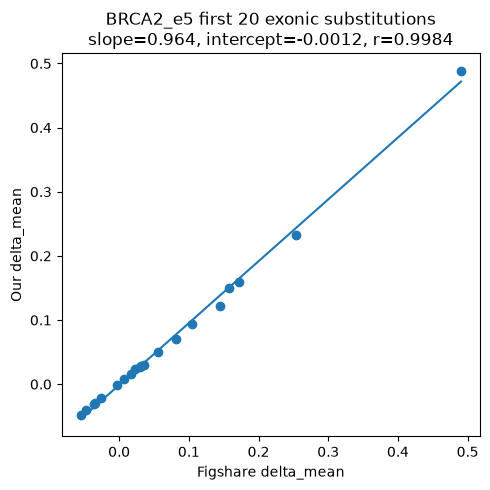

In [57]:
# 1. check linear relationship to Figshare
import matplotlib.pyplot as plt
from scipy.stats import linregress

x = results_df["figshare_delta_mean"]
y = results_df["ours_delta_mean"]

reg = linregress(x, y)

plt.figure(figsize=(5, 5))
plt.scatter(x, y)

xx = np.linspace(x.min(), x.max(), 100)
plt.plot(xx, reg.intercept + reg.slope * xx)

plt.xlabel("Figshare delta_mean")
plt.ylabel("Our delta_mean")
plt.title(
    f"BRCA2_e5 first 20 exonic substitutions\n"
    f"slope={reg.slope:.3f}, intercept={reg.intercept:.4f}, "
    f"r={reg.rvalue:.4f}"
)

plt.tight_layout()
plt.show()

In [58]:
# 2. quantify absolute error
for ours_col, fig_col in [
    ("ours_acceptor_mut", "figshare_acceptor_mut"),
    ("ours_donor_mut", "figshare_donor_mut"),
    ("ours_delta_acceptor", "figshare_delta_acceptor"),
    ("ours_delta_donor", "figshare_delta_donor"),
    ("ours_delta_mean", "figshare_delta_mean"),
]:
    err = results_df[ours_col] - results_df[fig_col]

    print(
        ours_col,
        "MAE =", np.mean(np.abs(err)),
        "mean bias =", np.mean(err)
    )

ours_acceptor_mut MAE = 0.012841796875 mean bias = -0.012841796875
ours_donor_mut MAE = 0.010382080078125 mean bias = -0.010382080078125
ours_delta_acceptor MAE = 0.00830078125 mean bias = -0.004541015625
ours_delta_donor MAE = 0.005609130859375 mean bias = -0.002813720703125
ours_delta_mean MAE = 0.0069183349609375 mean bias = -0.0036773681640625


In [59]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
from scipy import stats

# ------------------------------------------------------------
# helper: get regression stats
# ------------------------------------------------------------
def get_stats(x, y):
    x = np.asarray(x)
    y = np.asarray(y)

    mask = np.isfinite(x) & np.isfinite(y)
    x = x[mask]
    y = y[mask]

    if len(x) < 2 or np.ptp(x) == 0 or np.ptp(y) == 0:
        return None, None, None

    reg = stats.linregress(x, y)
    pearson_r, _ = stats.pearsonr(x, y)
    spearman_r, _ = stats.spearmanr(x, y)

    return x, y, {
        "n": len(x),
        "slope": reg.slope,
        "intercept": reg.intercept,
        "pearson": pearson_r,
        "spearman": spearman_r,
    }

# ------------------------------------------------------------
# helper: 2D histogram panel
# ------------------------------------------------------------
def plot_hist_panel(
    ax,
    x,
    y,
    xlabel,
    ylabel,
    panel_title,
    num_bins=35
):
    # clip only for DISPLAY, not for stats
    x_plot = x.copy()
    y_plot = y.copy()

    x_limits = np.quantile(x_plot, [0.001, 0.999])
    y_limits = np.quantile(y_plot, [0.001, 0.999])

    x_plot = np.clip(x_plot, x_limits[0], x_limits[1])
    y_plot = np.clip(y_plot, y_limits[0], y_limits[1])

    counts, xbins, ybins = np.histogram2d(
        x_plot, y_plot,
        bins=(num_bins, num_bins)
    )

    mesh = ax.pcolormesh(
        xbins,
        ybins,
        counts.T,
        cmap="Blues",
        norm=matplotlib.colors.LogNorm(vmin=0.6)
    )

    # regression line from UNCLIPPED valid data
    reg = stats.linregress(x, y)
    xline = np.linspace(x.min(), x.max(), 200)
    yline = reg.intercept + reg.slope * xline
    ax.plot(xline, yline, linewidth=2)

    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.set_title(panel_title)

    return mesh

# ------------------------------------------------------------
# main function: AlphaGenome vs PNAS for one exon
# ------------------------------------------------------------
def plot_alphagenome_vs_pnas_one_exon(
    df,
    exon_id,
    pnas_col="pretuner",
    mean_col="alphag_mean_logit",
    prod_col="alphag_prod_logit",
    save_path=None
):
    g = df[df["exon_id"] == exon_id].copy()

    if len(g) == 0:
        print(f"No rows found for exon_id = {exon_id}")
        return

    x_mean, y_mean, stats_mean = get_stats(
        g[pnas_col].to_numpy(),
        g[mean_col].to_numpy()
    )

    x_prod, y_prod, stats_prod = get_stats(
        g[pnas_col].to_numpy(),
        g[prod_col].to_numpy()
    )

    if stats_mean is None:
        print(f"Not enough valid data for mean-logit panel: {exon_id}")
        return
    if stats_prod is None:
        print(f"Not enough valid data for product-logit panel: {exon_id}")
        return

    fig, axes = plt.subplots(
        1, 2,
        figsize=(15, 5.5)
    )

    fig.suptitle(
        exon_id,
        fontsize=20,
        y=1.03
    )

    # left panel
    mesh0 = plot_hist_panel(
        axes[0],
        x_mean,
        y_mean,
        xlabel="PNAS pretuner (SR balance)",
        ylabel="AlphaGenome mean-logit score",
        panel_title=(
            "AlphaGenome mean-logit\n"
            f"n = {stats_mean['n']}\n"
            f"Slope = {stats_mean['slope']:.3f}, "
            f"Pearson r = {stats_mean['pearson']:.3f}\n"
            f"Spearman ρ = {stats_mean['spearman']:.3f}"
        )
    )
    cbar0 = plt.colorbar(mesh0, ax=axes[0])
    cbar0.set_label("Count")

    # right panel
    mesh1 = plot_hist_panel(
        axes[1],
        x_prod,
        y_prod,
        xlabel="PNAS pretuner (SR balance)",
        ylabel="AlphaGenome product-logit score",
        panel_title=(
            "AlphaGenome product-logit\n"
            f"n = {stats_prod['n']}\n"
            f"Slope = {stats_prod['slope']:.3f}, "
            f"Pearson r = {stats_prod['pearson']:.3f}\n"
            f"Spearman ρ = {stats_prod['spearman']:.3f}"
        )
    )
    cbar1 = plt.colorbar(mesh1, ax=axes[1])
    cbar1.set_label("Count")

    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=200, bbox_inches="tight")

    plt.show()

    return {
        "mean_stats": stats_mean,
        "prod_stats": stats_prod
    }

In [62]:
pnas_df = pd.read_csv(
    "../outputs/test_exons_with_pretuner.csv"
)

In [64]:
import numpy as np
from scipy.special import logit

acc_col = "alphagenome_minigene__alphagenome_minigene_acceptor_mut"
don_col = "alphagenome_minigene__alphagenome_minigene_donor_mut"

acc = df[acc_col]
don = df[don_col]

df["alphag_mut_acceptor_logit"] = logit(acc)
df["alphag_mut_donor_logit"] = logit(don)

df["alphag_mean_logit"] = df[
    ["alphag_mut_acceptor_logit", "alphag_mut_donor_logit"]
].mean(axis=1)

df["alphag_prod_logit"] = logit(acc * don)

In [65]:
ag_sub = df[
    (df["region"] == "Exon") &
    (df["mut_type"] == "sub")
].copy()

merged = pnas_df[
    ["variant_id", "exon_id", "pretuner"]
].merge(
    ag_sub[
        [
            "variant_id",
            "exon_id",
            "alphag_mean_logit",
            "alphag_prod_logit"
        ]
    ],
    on=["variant_id", "exon_id"],
    how="inner"
)

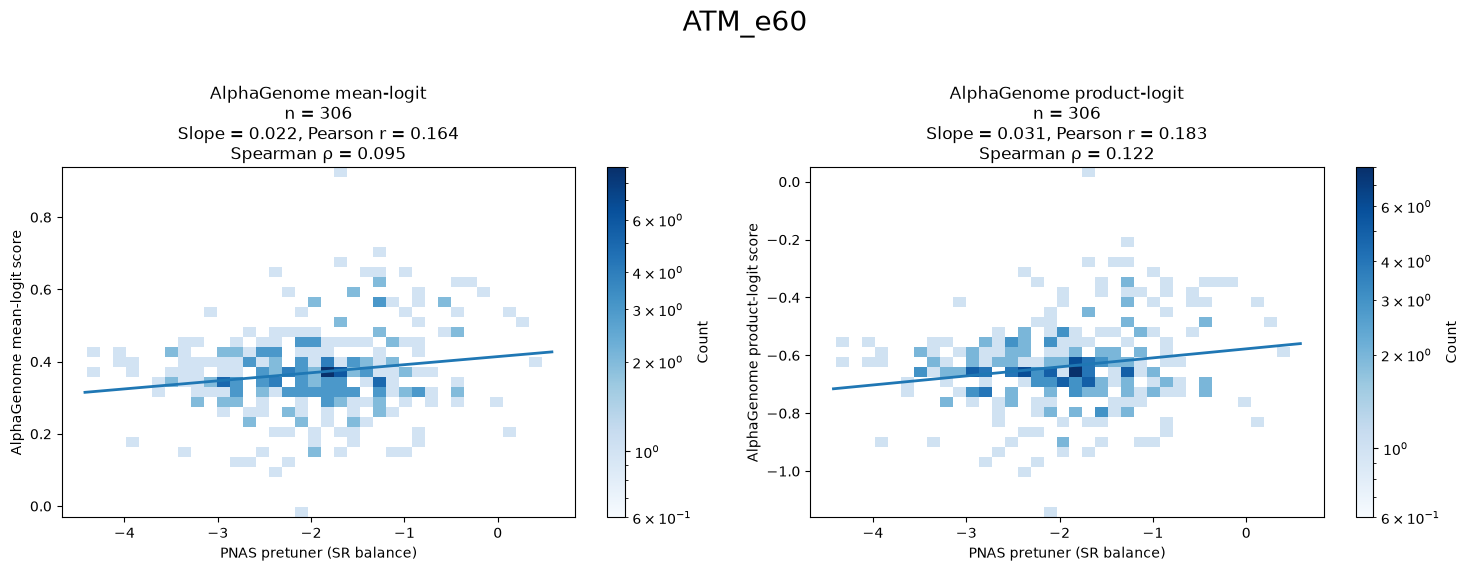

{'mean_stats': {'n': 306,
  'slope': np.float64(0.02237844095421316),
  'intercept': np.float64(0.41398139336744993),
  'pearson': np.float64(0.16449054326501858),
  'spearman': np.float64(0.0951537703396085)},
 'prod_stats': {'n': 306,
  'slope': np.float64(0.031209909455812087),
  'intercept': np.float64(-0.5774078181291737),
  'pearson': np.float64(0.18343817682868355),
  'spearman': np.float64(0.12202691598343636)}}

In [66]:
plot_alphagenome_vs_pnas_one_exon(
    merged,
    exon_id="ATM_e60"
)

In [67]:
# comparison of exon ATM_e60 with my pipeline

import numpy as np
import pandas as pd
from scipy.special import logit
from tqdm.auto import tqdm

In [68]:
exon_id = "ATM_e60"

atm_vars = df[
    (df["exon_id"] == exon_id) &
    (df["region"] == "Exon") &
    (df["mut_type"] == "sub")
].copy()

print("n variants:", len(atm_vars))

n variants: 306


In [69]:
row0 = atm_vars.iloc[0]

exon_len = int(row0["exon_length"])

acceptor_construct_pos0 = 216
donor_construct_pos0 = 216 + exon_len - 1


# ============================================================
# Reconstruct WT sequence once
# ============================================================

mut_seq0 = clean_seq(row0["nt_seq"])
mut_pos0 = int(row0["start"]) - 1

wt_seq = list(mut_seq0)
wt_seq[mut_pos0] = row0["REF"]
wt_seq = "".join(wt_seq)


# ============================================================
# Predict WT once
# ============================================================

wt_core = clean_seq(
    pre_manual + wt_seq + post_manual
)

wt_padded, wt_left_pad, _ = pad_construct(wt_core)

wt_acceptor_pos = wt_left_pad + acceptor_construct_pos0
wt_donor_pos = wt_left_pad + donor_construct_pos0

wt_out = dna_model.predict_sequence(
    sequence=wt_padded,
    organism=dna_client.Organism.HOMO_SAPIENS,
    requested_outputs=[
        dna_client.OutputType.SPLICE_SITES
    ],
    ontology_terms=["CL:0002518"],
)

wt_donor_track, wt_acceptor_track = (
    get_positive_strand_tracks(wt_out)
)

acceptor_wt = float(
    wt_acceptor_track[wt_acceptor_pos]
)

donor_wt = float(
    wt_donor_track[wt_donor_pos]
)

print("WT acceptor:", acceptor_wt)
print("WT donor:", donor_wt)

WT acceptor: 0.6484375
WT donor: 0.55078125


In [70]:
api_results = []

for _, row in tqdm(
    atm_vars.iterrows(),
    total=len(atm_vars)
):
    mut_seq = clean_seq(row["nt_seq"])

    mut_core = clean_seq(
        pre_manual + mut_seq + post_manual
    )

    mut_padded, mut_left_pad, _ = pad_construct(
        mut_core
    )

    mut_acceptor_pos = (
        mut_left_pad + acceptor_construct_pos0
    )

    mut_donor_pos = (
        mut_left_pad + donor_construct_pos0
    )

    mut_out = dna_model.predict_sequence(
        sequence=mut_padded,
        organism=dna_client.Organism.HOMO_SAPIENS,
        requested_outputs=[
            dna_client.OutputType.SPLICE_SITES
        ],
        ontology_terms=["CL:0002518"],
    )

    mut_donor_track, mut_acceptor_track = (
        get_positive_strand_tracks(mut_out)
    )

    acceptor_mut = float(
        mut_acceptor_track[mut_acceptor_pos]
    )

    donor_mut = float(
        mut_donor_track[mut_donor_pos]
    )

    api_results.append({
        "variant_id": row["variant_id"],
        "exon_id": row["exon_id"],

        "api_acceptor_wt": acceptor_wt,
        "api_donor_wt": donor_wt,

        "api_acceptor_mut": acceptor_mut,
        "api_donor_mut": donor_mut,

        "api_delta_acceptor":
            acceptor_mut - acceptor_wt,

        "api_delta_donor":
            donor_mut - donor_wt,
    })

api_df = pd.DataFrame(api_results)

I0906 22:04:08.707546 52113479 ev_poll_posix.cc:593] FD from fork parent still in poll list: fd(115, generation: 1)
100%|██████████| 306/306 [00:32<00:00,  9.56it/s]


In [72]:
api_df["api_acceptor_logit"] = logit(
    api_df["api_acceptor_mut"]
)

api_df["api_donor_logit"] = logit(
    api_df["api_donor_mut"]
)

api_df["api_mean_logit"] = (
    api_df[
        [
            "api_acceptor_logit",
            "api_donor_logit"
        ]
    ]
    .mean(axis=1)
)

api_df["api_prod_logit"] = logit(
    api_df["api_acceptor_mut"]
    *
    api_df["api_donor_mut"]
)

In [73]:
api_merged = pnas_df[
    [
        "variant_id",
        "exon_id",
        "pretuner"
    ]
].merge(
    api_df,
    on=["variant_id", "exon_id"],
    how="inner"
)

print(api_merged.shape)

display(
    api_merged[
        [
            "variant_id",
            "pretuner",
            "api_acceptor_mut",
            "api_donor_mut",
            "api_mean_logit",
            "api_prod_logit"
        ]
    ].head()
)

(306, 13)


,variant_id,pretuner,api_acceptor_mut,api_donor_mut,api_mean_logit,api_prod_logit
0,ATM_e60_T72A,-1.753182,0.671875,0.519531,0.397421,-0.623173
1,ATM_e60_T72C,-1.703269,0.699219,0.570312,0.563353,-0.410579
2,ATM_e60_T72G,-1.849508,0.660156,0.527344,0.386737,-0.627272
3,ATM_e60_G73A,-1.888088,0.625000,0.527344,0.310155,-0.710041
4,ATM_e60_G73C,-1.865136,0.617188,0.519531,0.277896,-0.750795


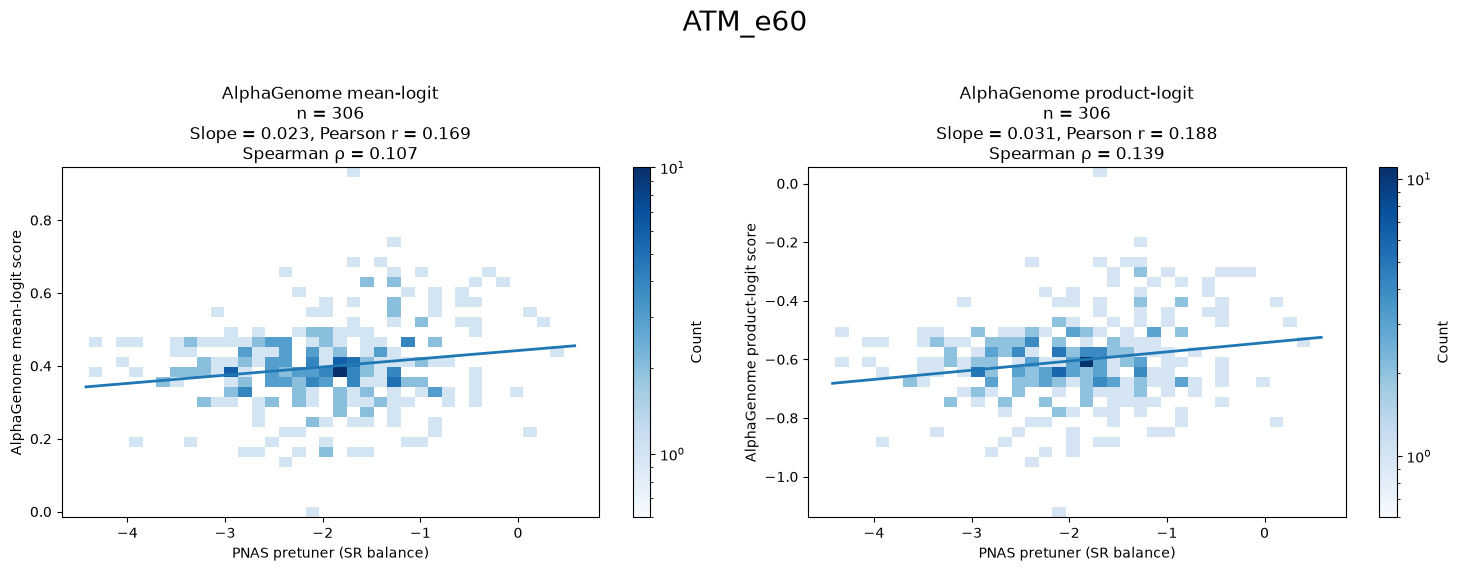

{'mean_stats': {'n': 306,
  'slope': np.float64(0.022543892259451817),
  'intercept': np.float64(0.4421641064841419),
  'pearson': np.float64(0.16855163545112173),
  'spearman': np.float64(0.10702669202782199)},
 'prod_stats': {'n': 306,
  'slope': np.float64(0.031348268690675585),
  'intercept': np.float64(-0.5430110042373572),
  'pearson': np.float64(0.18789530144334635),
  'spearman': np.float64(0.13896951352946127)}}

In [74]:
plot_alphagenome_vs_pnas_one_exon(
    api_merged,
    exon_id="ATM_e60",
    pnas_col="pretuner",
    mean_col="api_mean_logit",
    prod_col="api_prod_logit"
)